# Laptop Version Analysis
## Significant variables were established in SQL and now will have been done describing statistic.
## In describing statistic, the variables will be understood.

In [36]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

In [40]:
df = pd.read_pickle("master_laptop_data.pkl")

In [41]:
# Looking summary for numeric variables
df.describe()

,Laptop_ID,Discounted_Price,Actual_Price,Rating,Reviews
count,306.000000,3.060000e+02,2.910000e+02,26.000000,26.000000
mean,152.500000,2.775879e+06,3.212616e+06,9.461538,1.615385
std,88.478811,1.708020e+06,1.802598e+06,13.243053,1.134087
min,0.000000,8.599900e+05,1.119990e+06,3.000000,1.000000
25%,76.250000,1.742490e+06,2.000000e+06,5.000000,1.000000
50%,152.500000,2.344990e+06,2.800000e+06,5.000000,1.000000
75%,228.750000,3.449998e+06,3.800000e+06,5.000000,2.000000
max,305.000000,1.552999e+07,1.599900e+07,48.000000,5.000000


## Numeric variables interpretation:

Discount_Price:
The mean and median (50th percentile) are close to each other (approximately 10% difference). However, the quartile distribution does not appear normal. There is a gap of around 600,000 between the first quartile and the median, while the gap between the median and the third quartile is about 1,100,000. This suggests that the distribution of discount prices is not normal and is likely right-skewed. The minimum and maximum values are far from the quartiles, indicating the presence of potential outliers. The standard deviation is also relatively large compared to the mean (close to 1 million), which further supports the conclusion that the distribution is not normal.

Actual_Price:
The mean and median are close (around a 10% difference), which suggests a relatively balanced distribution. The quartiles are spread out but fairly symmetric. This may indicate a distribution with moderate kurtosis. The distance between the first quartile and the minimum, as well as between the median and the first quartile, is relatively similar. However, the maximum value is not equally distant from the third quartile, suggesting possible upper-end outliers. The standard deviation is relatively large compared to the mean, which indicates a wide spread in values, but the distribution does not appear strongly skewed.

Rating:
The median is almost half of the mean, indicating that outlier values are inflating the mean and creating a skewed distribution. The quartiles show repeated values, suggesting that many observations cluster around the value 5. The minimum value is acceptable, but the maximum value is significantly higher than the third quartile, indicating strong upper outliers. The standard deviation is larger than the mean, which further supports the presence of skewness, likely toward the right side of the distribution.

Reviews:
There is a large difference between the mean and median, indicating skewness. The first and second quartiles have similar values, while the third quartile is approximately twice as large, suggesting a right-skewed distribution. The minimum value is similar to the first and second quartiles, but the maximum value is about 2.5 times larger than the third quartile, further supporting right skewness. The standard deviation is also much larger than the mean, reinforcing the presence of significant variability and skewness in the distribution.

In [42]:
# Looking summary for categorical variables
cat_cols = ["Brand", "Core", "SSD", "Series", "Processor", "RAM", "Storage"]
for col in cat_cols:
    freq = df[col].value_counts()
    ratio = df[col].value_counts(normalize=True) * 100
    
    freq_table = pd.DataFrame({
        "Frequency": freq,
        "Percent (%)": ratio.round(2)
    })
    
    print(f"\n--- {col} ---")
    display(freq_table)


--- Brand ---


,Frequency,Percent (%)
Brand,,
HP,110,35.95
Lenovo,88,28.76
Asus,34,11.11
Dell,32,10.46
Apple,21,6.86
Acer,14,4.58
Infinix,7,2.29



--- Core ---


,Frequency,Percent (%)
Core,,
Core i7,50,22.83
Core i5,46,21.00
Ultra 7,32,14.61
Ultra 5,17,7.76
Core i3,13,5.94
Ultra 9,12,5.48
Ryzen 5,11,5.02
M3,9,4.11
Ryzen 7,7,3.20



--- SSD ---


...

,Frequency,Percent (%)
Processor,,
Intel Core i7,79,30.38
Intel Core i5,69,26.54
Intel Core Ultra 7,33,12.69
Intel Core Ultra 5,18,6.92
Intel Core i3,17,6.54
AMD Ryzen 5,11,4.23
Apple M3,9,3.46
Intel Core i9,9,3.46
AMD Ryzen 7,8,3.08



--- RAM ---


,Frequency,Percent (%)
RAM,,
8GB,133,54.96
16GB,83,34.30
32GB,18,7.44
4GB,7,2.89
64GB,1,0.41



--- Storage ---


,Frequency,Percent (%)
Storage,,
512GB SSD,172,68.8
1TB SSD,54,21.6
256GB SSD,18,7.2
2TB SSD,6,2.4


In [43]:
from IPython.display import display

# Define the categorical columns for analysis
cat_cols = ["Brand", "Core", "SSD", "Series", "Processor", "RAM", "Storage"]

for col in cat_cols:
    if col in df.columns:
        # 1. Calculate frequency and percentage ratio
        freq = df[col].value_counts()
        ratio = (df[col].value_counts(normalize=True) * 100).round(2)
        
        # 2. Construct the frequency table
        freq_table = pd.DataFrame({
            "Frequency": freq,
            "Percentage (%)": ratio
        })
        
        # 3. Print the section header in English
        print(f"\n{'='*20}\n{col} ANALYSIS\n{'='*20}")
        
        # 4. Display the table using the IPython display function
        if not freq_table.empty:
            display(freq_table) 
        else:
            print(f"No data found for the column: {col}")
    else:
        print(f"Warning: The column '{col}' does not exist in the dataframe!")


Brand ANALYSIS


,Frequency,Percentage (%)
Brand,,
HP,110,35.95
Lenovo,88,28.76
Asus,34,11.11
Dell,32,10.46
Apple,21,6.86
Acer,14,4.58
Infinix,7,2.29



Core ANALYSIS


,Frequency,Percentage (%)
Core,,
Core i7,50,22.83
Core i5,46,21.00
Ultra 7,32,14.61
Ultra 5,17,7.76
Core i3,13,5.94
Ultra 9,12,5.48
Ryzen 5,11,5.02
M3,9,4.11
Ryzen 7,7,3.20



SSD ANALYSIS


...

,Frequency,Percentage (%)
Processor,,
Intel Core i7,79,30.38
Intel Core i5,69,26.54
Intel Core Ultra 7,33,12.69
Intel Core Ultra 5,18,6.92
Intel Core i3,17,6.54
AMD Ryzen 5,11,4.23
Apple M3,9,3.46
Intel Core i9,9,3.46
AMD Ryzen 7,8,3.08



RAM ANALYSIS


,Frequency,Percentage (%)
RAM,,
8GB,133,54.96
16GB,83,34.30
32GB,18,7.44
4GB,7,2.89
64GB,1,0.41



Storage ANALYSIS


,Frequency,Percentage (%)
Storage,,
512GB SSD,172,68.8
1TB SSD,54,21.6
256GB SSD,18,7.2
2TB SSD,6,2.4


## Interpretation:

HP and Lenovo are the most commonly preferred brands, and together they account for approximately two-thirds of the total market.

Regarding processor types, Intel is generally the dominant brand. However, Core i7 and Core i5 have very similar shares. Additionally, the Ultra 7 model is also relatively close to these two categories, while the remaining models are significantly less frequent. Therefore, we cannot conclude that there is a single clearly dominant processor model.

512GB SSD storage is highly dominant compared to other storage capacities.

The distribution of the series variable is unclear, as it accounts for only about one-fifth of the total observations and is fragmented across several categories. Therefore, it is not possible to make a reliable interpretation for this variable without further preprocessing, such as imputation and statistical testing.

Intel Core i7 and Core i5 processors are the most commonly preferred models. Other Intel processor types also show considerable frequency, indicating overall dominance of Intel-based systems.

For RAM, 8GB configurations account for more than half of the observations, while 16GB RAM is the second most common option. Therefore, these two RAM sizes are the most frequently used configurations in the dataset.

Finally, 512GB storage capacity is preferred over other available storage options.

In [44]:
# Visulation to the graphs

## Describing variable for drawing

numCols = ["Discounted_Price", "Actual_Price", "Rating", "Reviews"]

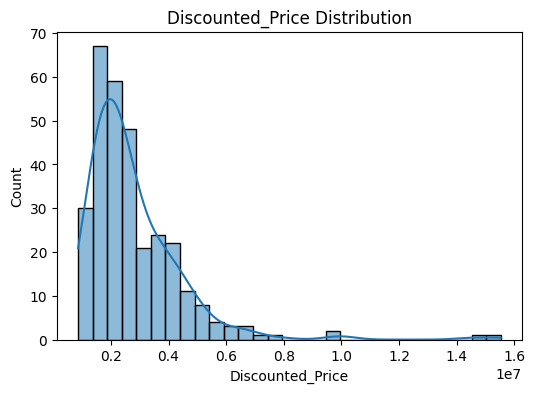

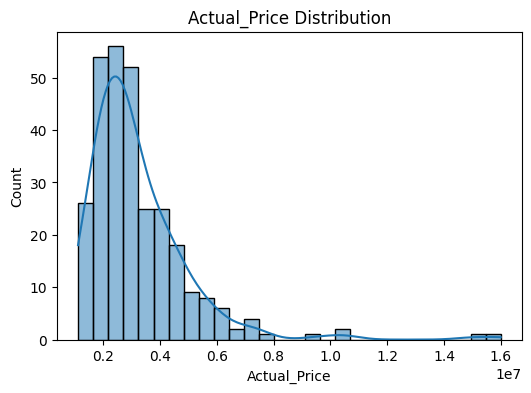

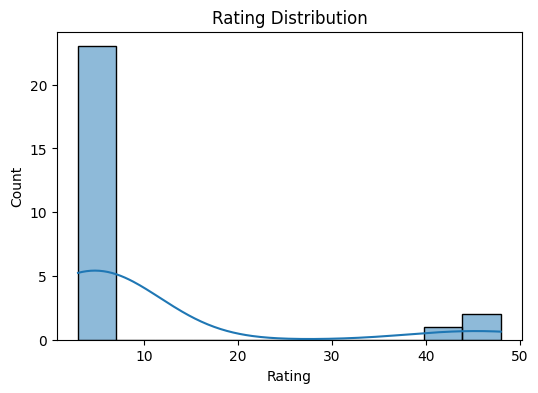

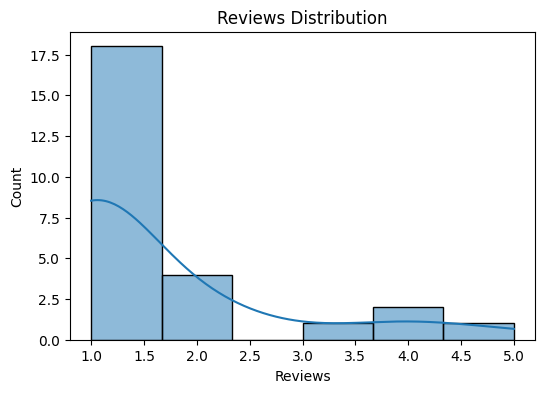

In [45]:
## Histograms

for col in numCols:
    plt.figure(figsize=(6, 4))
    sbn.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

## Interpretation:
The Discounted Price and Actual Price variables appear to follow similar distributions. Therefore, it is likely that both variables are influenced by the same product models, and there may be a significant relationship between them.

Both distributions are slightly left-skewed, although they also contain some outlier values. If these outliers are removed or appropriate transformations are applied, the distributions may become closer to normal; however, a fully normal distribution is still unlikely.

The Rating and Reviews variables are highly skewed. In particular, a single dominant value appears to be very frequent. Therefore, it is unlikely that these variables will show strong or meaningful relationships with other variables in the dataset.

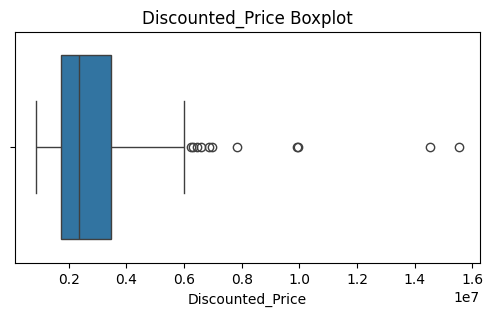

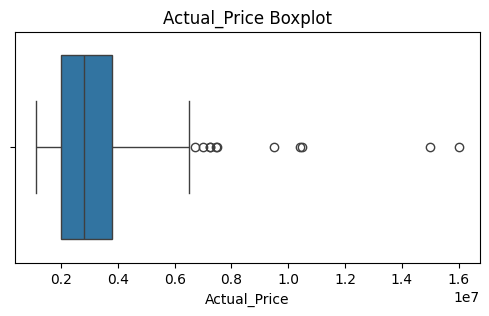

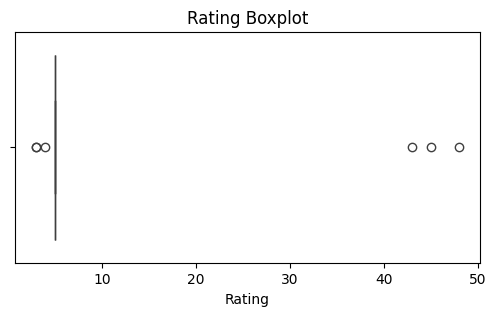

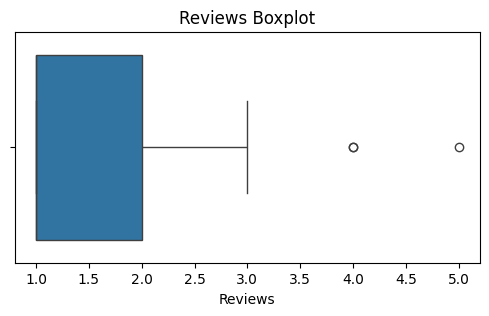

In [46]:
# Boxplot

for col in numCols:
    plt.figure(figsize=(6, 3))
    sbn.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

## Interpretation:
Discounted Price and Actual Price share similar outlier patterns. In both variables, outlier values are concentrated roughly in the range of 0.6–0.8, and both distributions also include values extending up to approximately 1.6.

The Rating variable does not show a clear distribution pattern. This is more easily observed in the histogram than in other visualizations. Overall, the values appear heavily concentrated rather than forming a continuous distribution.

The Reviews boxplot shows a concentration of values between 1 and 2. Additionally, there are two outlier points around 4 and 5. This indicates that the variable is not a continuous numeric variable but rather a discrete one. In practice, the data mainly consists of two dominant values (1 and 2), meaning there is no meaningful distributional spread or variation.

<function matplotlib.pyplot.show(close=None, block=None)>

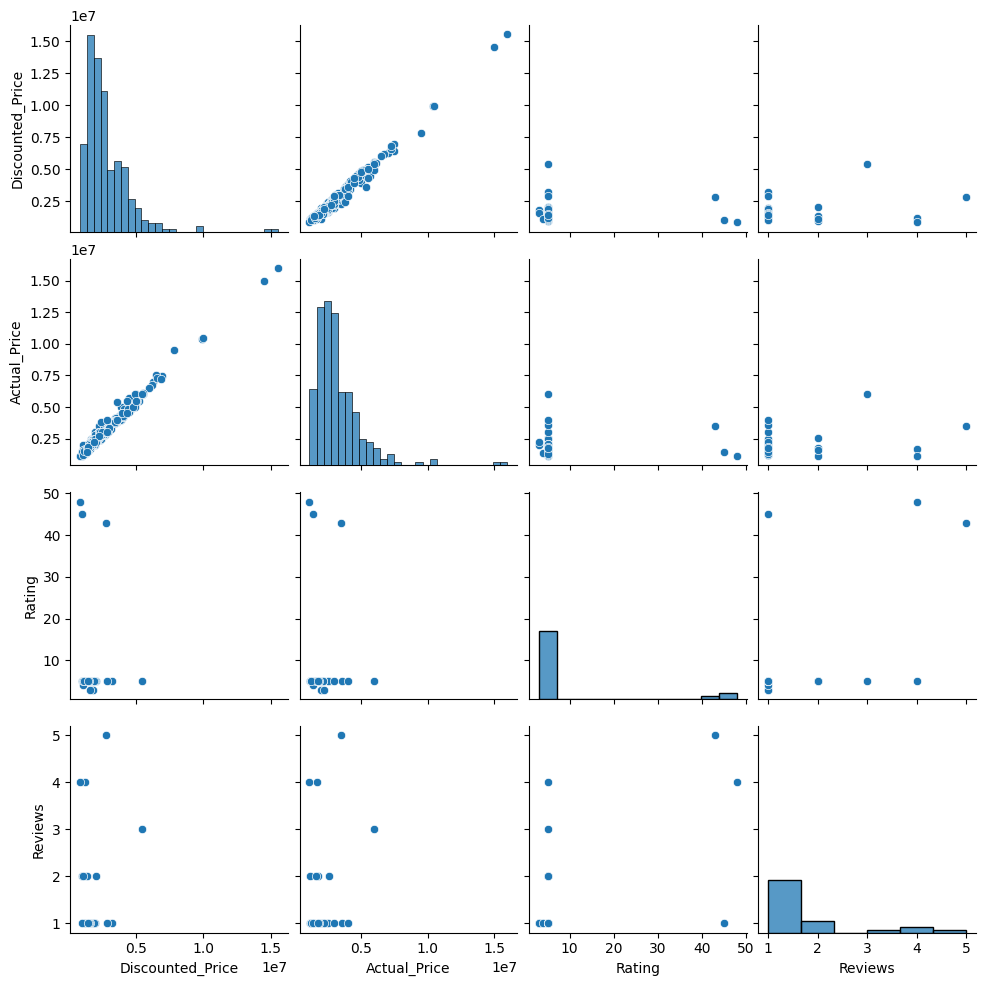

In [47]:
## Relaiton Graphs

sbn.pairplot(df[numCols])
plt.show

In [48]:
# Chisquare indepented tests for categorical tests

## Library 

from scipy.stats import chi2_contingency
import itertools

## Inferential Statistic for Relationship Between the Variables

In [49]:
## Chisquare test

results = []

for col1, col2 in itertools.combinations(cat_cols, 2):
    contingency = pd.crosstab(df[col1], df[col2])

    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        results.append({
            "Variable_1": col1,
            "Variable_2": col2,
            "Chi2": chi2,
            "p_value": p,
            "Independent": "No" if p < 0.05 else "Yes"
        })

chiSquareResults = pd.DataFrame(results)

chiSquareResults.sort_values("p_value")

,Variable_1,Variable_2,Chi2,p_value,Independent
8,Core,Processor,2403.371212,0.000000e+00,No
2,Brand,Series,1631.273193,6.916109e-244,No
7,Core,Series,977.395292,2.850245e-55,No
15,Series,Processor,778.720797,3.111180e-44,No
3,Brand,Processor,363.458133,1.713582e-40,No
20,RAM,Storage,192.439176,1.181464e-34,No
0,Brand,Core,357.914278,1.252521e-33,No
10,Core,Storage,212.012409,1.486799e-24,No
14,SSD,Storage,78.324672,8.742312e-19,No
19,Processor,Storage,148.849250,1.138648e-15,No


## Interpretation:
There is independence between the variables Brand–Storage, Brand–SSD, and SSD–Series.

This indicates that some brands offer a wide variety of storage and RAM configurations. In addition, the market shows a weighted preference for different RAM and storage options rather than a uniform distribution across brands.

The independence between SSD and Series also suggests that certain brands do not exhibit a consistent or uniform preference pattern across product series. Instead, storage and series choices vary significantly depending on the brand.

In [50]:
## Test of normality

from scipy.stats import shapiro

for col in numCols:
    stat, p = shapiro(df[col].dropna())
    print(f"{col}: p-value = {p: .5f}")

Discounted_Price: p-value =  0.00000
Actual_Price: p-value =  0.00000
Rating: p-value =  0.00000
Reviews: p-value =  0.00000


In [51]:
## Test of homogenity

from scipy.stats import levene

groups = [
    df[df["Brand"] == brand] ["Discounted_Price"].dropna()
    for brand in df["Brand"].unique()
]

stat, p = levene(*groups)
print("Levene p-value: ", p)

Levene p-value:  0.10550240063378076


## Interpretation:
The numeric variables do not satisfy the assumption of normality; however, they do exhibit homogeneity of variance.

In [52]:
## Correlation test

## The numeric variables exhibit asymmetric (non-normal) distributions. Therefore, the assumptions required for the 
## Pearson correlation test are not satisfied.

## Instead, the non-parametric alternative, the Spearman rank correlation test, will be used to assess the relationships between variables.

df[numCols].corr(method="spearman")

,Discounted_Price,Actual_Price,Rating,Reviews
Discounted_Price,1.000000,0.975745,-0.153835,-0.056209
Actual_Price,0.975745,1.000000,-0.132057,-0.025168
Rating,-0.153835,-0.132057,1.000000,0.409763
Reviews,-0.056209,-0.025168,0.409763,1.000000


## Interpretation:
Discounted Price and Actual Price exhibit a strong positive correlation. This suggests that both variables are driven by similar underlying factors, and changes in one are closely associated with changes in the other.

In contrast, Rating and Reviews do not show a meaningful relationship with either Actual Price or Discounted Price. Their impact on pricing appears to be minimal.

Additionally, Rating and Reviews have only a weak correlation with each other, indicating a limited relationship between these two variables.

<function matplotlib.pyplot.show(close=None, block=None)>

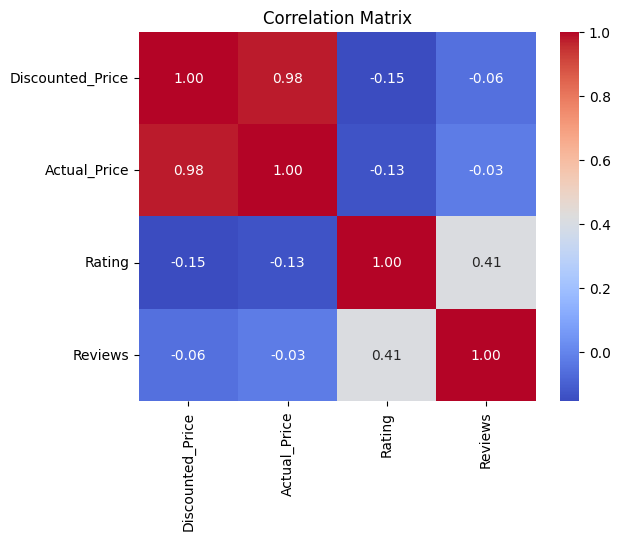

In [53]:
## Correlation Graph

sbn.heatmap(
    df[numCols].corr(method="spearman"),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show

In [54]:
## Relationship between categoric and numeric variables

from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova, permdisp
import pandas as pd

# Step 1: Prepare Numeric Data (Handle missing values)
# Ensure numCols is defined before this step
X_filled = df[numCols].fillna(df[numCols].median())
X_filled.index = X_filled.index.astype(str)

# Step 2: Create Distance Matrix (This might take a moment)
print("Calculating Distance Matrix...")
dm = DistanceMatrix(squareform(pdist(X_filled, metric='euclidean')), ids=X_filled.index)

# Step 3: Run Tests
final_results = []
print("Running PERMANOVA & PERMDISP tests...")

for factor in cat_cols:
    # Handle missing categories and ensure string type
    grouping = df[factor].fillna("Missing").astype(str)
    grouping.index = grouping.index.astype(str)
    
    # Reducing permutations to 499 can speed up the process while remaining statistically valid
    perm = permanova(dm, grouping, permutations=999) 
    disp = permdisp(dm, grouping, permutations=999)

    if perm["p-value"] < 0.05 and disp["p-value"] >= 0.05:
        decision = "Significant (clean)"
    elif perm["p-value"] < 0.05 and disp["p-value"] < 0.05:
        decision = "Significant (dispersion issue)"
    else:
        decision = "Not significant"

    final_results.append({
        "factor": factor,
        "permanova_p": perm["p-value"],
        "permdisp_p": disp["p-value"],
        "decision": decision
    })

# Step 4: Display Results
results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values("permanova_p").reset_index(drop=True)
display(results_df)

Calculating Distance Matrix...
Running PERMANOVA & PERMDISP tests...


,factor,permanova_p,permdisp_p,decision
0,Brand,0.001,0.092,Significant (clean)
1,Core,0.001,0.001,Significant (dispersion issue)
2,Series,0.001,0.001,Significant (dispersion issue)
3,Processor,0.001,0.001,Significant (dispersion issue)
4,Storage,0.001,0.001,Significant (dispersion issue)
5,RAM,0.001,0.293,Significant (clean)
6,SSD,0.013,0.028,Significant (dispersion issue)


## Interpretation:
The PERMANOVA test results indicate that all categorical variables have a significant effect on the numeric variables.

Additionally, the PERMDISP results show that, with the exception of RAM, all categorical variables significantly affect the variance of the numeric variables.

Next, we will examine the post hoc test results to interpret the relationships between individual variable pairs in more detail.

In [55]:
## Post-Hoc Test

from skbio.stats.distance import permanova
import itertools

# Create a dictionary to store all results
all_pairwise_results = {}

for factor in cat_cols:
    if factor in df.columns:
        # Prepare the grouping for the specific factor
        grouping = df[factor].fillna("Unknown").astype(str)
        grouping.index = df.index.astype(str)
        
        # Check if the factor has at least 2 unique groups to compare
        if len(grouping.unique()) > 1:
            print(f"\nComputing Pairwise for: {factor}...")
            pairwise_result = run_pairwise_permanova(dm, grouping)
            all_pairwise_results[factor] = pairwise_result
            
            # Display the top 10 most significant differences for each factor
            display(pairwise_result.head(10))
        else:
            print(f"Skipping {factor}: Not enough unique groups.")

# To access a specific result later, e.g., for SSD:
# display(all_pairwise_results['SSD'])


Computing Pairwise for: Brand...


NameError: name 'run_pairwise_permanova' is not defined

## Interpretation
According to the results, Brand 10, 11, 14, and 20 do not show statistically significant differences, whereas the remaining brands do. This suggests that price differences exist among most brands, indicating that brand choice generally has a significant effect on pricing.

The Core variable does not show any statistically significant differences. Therefore, processor core types do not appear to have a meaningful impact on either discounted or actual prices.

In contrast, SSD and storage variables have a significant effect on prices, indicating that storage capacity is an important determinant of product pricing.

For RAM, the 4GB, 8GB, 16GB, and 64GB categories do not show significant differences among each other. This suggests that RAM size, within these categories, may not strongly influence price differentiation.

Processor types do not exhibit significant relationships with prices. One possible explanation is that customers may not prioritize or fully understand technical processor specifications, leading to a limited impact on pricing.

Similarly, product series do not show a significant effect on prices. This may indicate that customers are less influenced by brand series and instead focus more on tangible features such as storage and RAM capacity.

## Final Interpretation:

The numeric variables—Discounted Price, Actual Price, Rating, and Reviews—do not follow a normal distribution; however, they satisfy the assumption of homogeneity of variance.

There is a significant positive correlation between Actual Price and Discounted Price, indicating that these two variables are strongly related. In contrast, Rating and Reviews do not show significant relationships either with each other or with the price variables.

Among the categorical variables, Brand–Storage, Brand–SSD, and SSD–Series pairs exhibit independence, while other categorical relationships show dependence.

According to the results, Core type, Processor type, and Product Series do not have a significant effect on Discounted Price, Actual Price, Rating, or Reviews. In contrast, Brand, Storage capacity, RAM size, and SSD presence significantly influence pricing.

Overall, this suggests that pricing is primarily driven by tangible hardware features such as storage capacity and RAM, as well as brand factors. Product series and processor specifications appear to have limited influence. From a behavioral perspective, this may indicate that customers prioritize easily comparable features (e.g., storage and RAM) and rely on brand recognition, while paying less attention to more technical specifications such as processor details or product series.